In [8]:
!pip install -U langgraph

In [9]:
!pip install langchain-groq

In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver

In [11]:
from google.colab import userdata
groq_api_key=userdata.get('GROQ_API_KEY')

In [12]:
llm=ChatGroq(model="openai/gpt-oss-20b",api_key=groq_api_key)

In [13]:
class JokeState(TypedDict):
  topic:str
  joke:str
  explanation:str

In [19]:
def generate_joke(state:JokeState):
  prompt=f"generate a joke on the topic {state['topic']}"
  response=llm.invoke(prompt).content
  return {'joke':response}


def generate_explanation(state:JokeState):
  prompt=f"write an explanation for the joke {state['joke']}"
  response=llm.invoke(prompt).content
  return {'explanation':response}


In [20]:
graph=StateGraph(JokeState)
graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)
checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)

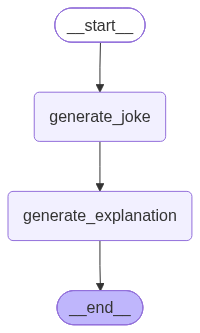

In [21]:
workflow

In [29]:
config1={"configurable":{'thread_id':1}}
response=workflow.invoke({'topic':"football"},config=config1)

In [30]:
response['explanation']

'**Why the joke works**\n\n1. **The double meaning of “tie”**  \n   - In football (or any sport), to *tie* a game means the two teams finish with the same number of points – the score is “even” or “drawn.”  \n   - The verb *to tie* also means to fasten something with a cord, rope, or string.\n\n2. **The literal vs. figurative misunderstanding**  \n   - The joke imagines the football team hearing the phrase “tie the score” and taking it *literally*: they think they need to physically bind the scoreboard or the points together with a piece of string.  \n   - In reality, “tie the score” is just a way of saying the game ends in a draw; no string is involved.\n\n3. **The punchline**  \n   - “Because they heard they needed to tie the score!” flips the idiom on its head.  \n   - The audience laughs because the team’s “solution” is absurdly literal—bringing string to the game to “tie” the score.\n\n**Bottom line**\n\nThe humor comes from the play on words: “tie” as a sports term (a draw) versu

In [31]:
len(list(workflow.get_state_history(config1)))

12

In [36]:
config2={"configurable":{"thread_id":"2"}}
workflow.invoke({'topic':"Cricket"},config=config2)

{'topic': 'Cricket',
 'joke': 'Why did the cricket team go to the bank?\n\nBecause they heard it was a good place to “take a wicket” and “score a few runs”!',
 'explanation': '### Why the joke works\n\n| Element of the joke | Cricket meaning | Banking meaning (or lack thereof) | Why it’s funny |\n|----------------------|-----------------|------------------------------------|----------------|\n| **“Take a wicket”** | In cricket, a bowler “takes a wicket” when he dismisses a batsman. | There is no real banking action called “taking a wicket.” The only “wicket” a bank has is a small door or gate, which is a completely different thing. | The humor comes from the literal, absurd idea that a cricket team would go to a bank just so they could *physically* take a wicket—like grabbing the bank’s door. |\n| **“Score a few runs”** | In cricket, “runs” are the points a team earns by running between the wickets. | In banking, “runs” can colloquially mean money, but you don’t “score” them in the sam

In [37]:
len(workflow.get_state(config2))

8